# Advanced Methods: Causal ML, GNNs, and AutoML — Complete Guide
### Machine-Learning Algorithm Selection Framework | Notebook 6 of 6

> **Companion notebook to:** *A Reproducible Framework for Machine Learning Algorithm Selection* (Alsammani, Delaware State University)

This notebook covers three advanced paradigms from the manuscript that go beyond standard supervised/unsupervised learning:

1. **Causal Machine Learning** - estimating intervention effects (ATE, CATE)
2. **Graph Neural Networks (GNNs)** - learning on graph-structured data
3. **AutoML and Hyperparameter Optimization** - automating the ML pipeline


---
## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    mean_squared_error, r2_score, roc_auc_score, accuracy_score
)

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False
    print('optuna not installed.  Run:  pip install optuna')

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42
np.random.seed(SEED)
print('Setup complete.')


optuna not installed.  Run:  pip install optuna
Setup complete.


---
# 1. Causal Machine Learning
## Framework

Standard ML optimizes predictive accuracy under a fixed distribution. Causal ML targets
estimation of the effect of **interventions** $\mathrm{do}(T=t)$ in Pearl's do-calculus.

**Key quantities:**

| Estimand | Formula | Meaning |
|---|---|---|
| ATE | $\tau = \mathbb{E}[Y(1)-Y(0)]$ | Average effect across all units |
| CATE | $\tau(\mathbf{x}) = \mathbb{E}[Y(1)-Y(0)|\mathbf{X}=\mathbf{x}]$ | Heterogeneous effect by subgroup |
| ATT | $\mathbb{E}[Y(1)-Y(0)|T=1]$ | Effect on the treated units |

**Identification requires:**
- **Unconfoundedness:** $\{Y(0),Y(1)\} \perp T \mid \mathbf{X}$
- **Overlap:** $0 < P(T=1|\mathbf{X}) < 1$

## Key Methods

| Method | Approach | Strength |
|---|---|---|
| S-Learner | Single model; estimate CATE as difference | Simple; may underfit treatment heterogeneity |
| T-Learner | Separate models per group | Flexible; amplifies error in small groups |
| Double ML (DML) | Residual-on-residual; cross-fitting | $\sqrt{n}$-convergence despite slow nuisance models |
| Causal Forest | Honest random forest; asymptotic normality | Heterogeneous effects; valid CIs |

**Double/Debiased ML (DML):** The partially linear model $Y = \tau T + g(\mathbf{X}) + \varepsilon$ yields:

$$\tilde{Y} = \tau\tilde{T} + \varepsilon, \qquad \tilde{Y}=Y-\hat{\ell}(\mathbf{X}), \quad \tilde{T}=T-\hat{m}(\mathbf{X})$$

where $\hat{\ell}$ and $\hat{m}$ are nuisance models estimated on held-out folds (cross-fitting).

## When to Use / Avoid

| | Condition |
|---|---|
| **Use** | Goal is intervention effect, not prediction; A/B testing infeasible; personalized treatment |
| **Avoid** | Only predictive accuracy needed; causal assumptions cannot be defended |

**Primary domains:** Healthcare, economics, technology (A/B augmentation), uplift modeling.


In [2]:
# Simulate a randomized controlled trial with heterogeneous treatment effects
np.random.seed(SEED)
n = 2000

# Covariates
X_caus = np.random.randn(n, 4)
X_caus[:, 0] = np.abs(X_caus[:, 0])          # age proxy (>0)
X_caus[:, 1] = (X_caus[:, 1] > 0).astype(float)  # binary covariate

# Propensity score and treatment assignment
propensity = 1 / (1 + np.exp(-(0.3*X_caus[:,0] - 0.5*X_caus[:,1])))
T = (np.random.rand(n) < propensity).astype(float)

# True CATE: heterogeneous - effect larger for high X0, small for low X1
true_cate = 2.0 + 1.5*X_caus[:,0] - 1.0*X_caus[:,1]

# Outcome: confounded
noise = np.random.randn(n)
Y = 3*X_caus[:,0] - 2*X_caus[:,1] + true_cate*T + noise

print(f'Dataset: n={n}, 4 covariates')
print(f'Treatment rate: {T.mean():.3f}')
print(f'True ATE: {true_cate.mean():.3f}')
print(f'Naive difference in means (biased): {Y[T==1].mean() - Y[T==0].mean():.3f}')

# T-Learner
X_tr_c, X_te_c, T_tr, T_te, Y_tr, Y_te, cate_tr, cate_te = train_test_split(
    X_caus, T, Y, true_cate, test_size=0.3, random_state=SEED)

rf1 = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf0 = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf1.fit(X_tr_c[T_tr==1], Y_tr[T_tr==1])
rf0.fit(X_tr_c[T_tr==0], Y_tr[T_tr==0])
cate_t_learner = rf1.predict(X_te_c) - rf0.predict(X_te_c)

print(f'T-Learner estimated ATE:  {cate_t_learner.mean():.3f}')
print(f'T-Learner RMSE(CATE):     {np.sqrt(mean_squared_error(cate_te, cate_t_learner)):.4f}')


Dataset: n=2000, 4 covariates
Treatment rate: 0.491
True ATE: 2.700
Naive difference in means (biased): 3.399
T-Learner estimated ATE:  2.759
T-Learner RMSE(CATE):     0.6910


Double ML estimated ATE:  2.6659
95% CI: [2.5547, 2.7771]
True ATE: 2.7005



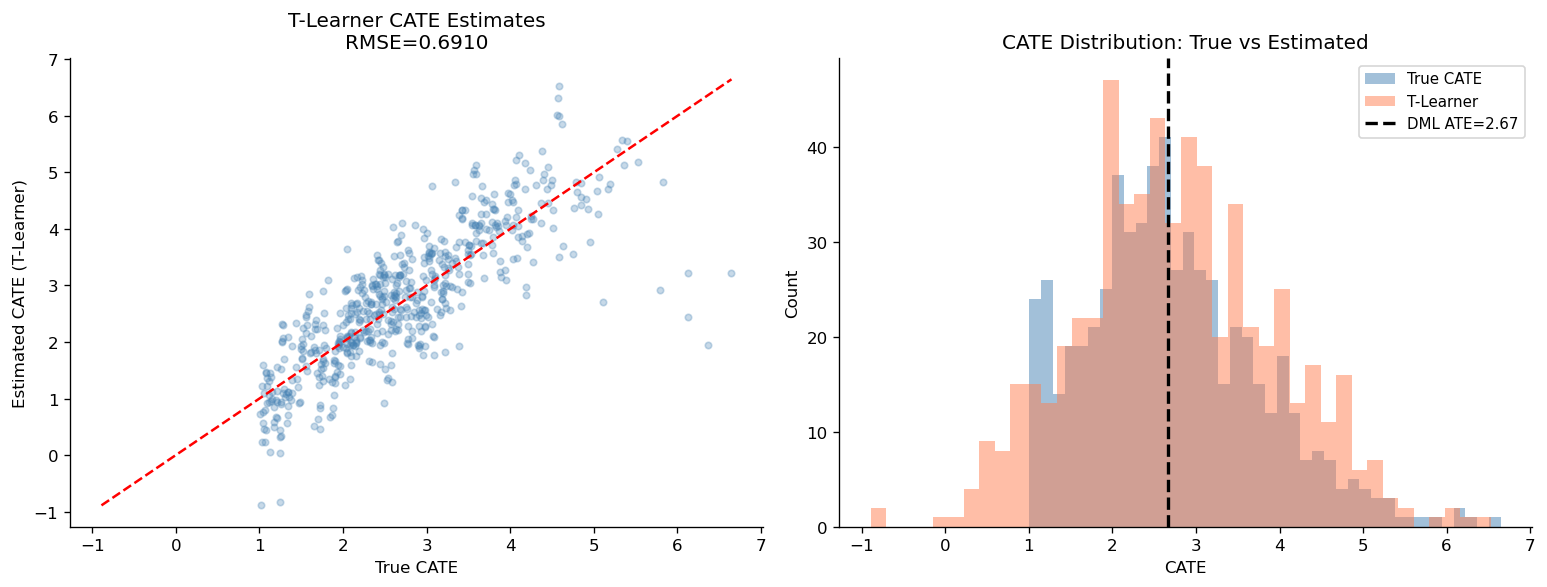

In [3]:
# Double ML (manual cross-fitting implementation)
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
Y_res = np.zeros(n)
T_res = np.zeros(n)

for tr_idx, te_idx in kf.split(X_caus):
    # Nuisance model for outcome
    m_y = RandomForestRegressor(n_estimators=100, random_state=SEED)
    m_y.fit(X_caus[tr_idx], Y[tr_idx])
    Y_res[te_idx] = Y[te_idx] - m_y.predict(X_caus[te_idx])
    # Nuisance model for treatment
    m_t = RandomForestRegressor(n_estimators=100, random_state=SEED)
    m_t.fit(X_caus[tr_idx], T[tr_idx])
    T_res[te_idx] = T[te_idx] - m_t.predict(X_caus[te_idx])

# Final stage: regress residual outcome on residual treatment
ate_dml = np.sum(T_res * Y_res) / np.sum(T_res**2)
se_dml  = np.std(T_res * Y_res - ate_dml * T_res**2) / (np.abs(np.sum(T_res**2)/n) * np.sqrt(n))
ci_lo, ci_hi = ate_dml - 1.96*se_dml, ate_dml + 1.96*se_dml

print(f'Double ML estimated ATE:  {ate_dml:.4f}')
print(f'95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'True ATE: {true_cate.mean():.4f}')
print()

# Visualization: CATE heterogeneity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(cate_te, cate_t_learner, alpha=0.3, s=15, color='steelblue')
lims = [min(cate_te.min(), cate_t_learner.min()),
        max(cate_te.max(), cate_t_learner.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('True CATE'); axes[0].set_ylabel('Estimated CATE (T-Learner)')
axes[0].set_title(f'T-Learner CATE Estimates\nRMSE={np.sqrt(mean_squared_error(cate_te,cate_t_learner)):.4f}')

axes[1].hist(cate_te, bins=40, alpha=0.5, label='True CATE', color='steelblue')
axes[1].hist(cate_t_learner, bins=40, alpha=0.5, label='T-Learner', color='coral')
axes[1].axvline(ate_dml, color='black', lw=2, linestyle='--', label=f'DML ATE={ate_dml:.2f}')
axes[1].set_xlabel('CATE'); axes[1].set_ylabel('Count')
axes[1].set_title('CATE Distribution: True vs Estimated'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


### Interpretation

- The **naive difference-in-means** is biased because treatment assignment is correlated with covariates (confounding).
- **Double ML** removes confounding bias by partialing out the effects of $\mathbf{X}$ on both $Y$ and $T$ before estimating $\tau$.
- The **T-Learner** captures CATE heterogeneity but is noisier in small treatment groups.
- A high-quality CATE estimator enables **personalized treatment policy**: administer treatment to units where $\tau(\mathbf{x}) > 0$ (or above a cost threshold).

**Further reading and tools:**
- `EconML` (Microsoft): `pip install econml` — Causal Forests, DML, IV
- `DoWhy` (Microsoft): `pip install dowhy` — Structural causal models
- `causalml` (Uber): `pip install causalml` — Uplift modeling


---
# 2. Graph Neural Networks (GNNs)
## Mathematical Foundation

GNNs generalize neural networks to graph-structured data $\mathcal{G}=(V,E,\mathbf{X})$.
The general **message-passing** framework updates node representations over $L$ layers:

$$\mathbf{h}_v^{(l)} = \phi^{(l)}\!\left(\mathbf{h}_v^{(l-1)},\; \bigoplus_{u\in\mathcal{N}(v)} \psi^{(l)}\!\left(\mathbf{h}_v^{(l-1)},\mathbf{h}_u^{(l-1)},e_{uv}\right)\right)$$

where $\bigoplus$ is a permutation-invariant aggregation (sum, mean, or max).

**Key architectures:**

| Model | Aggregation | Strength |
|---|---|---|
| GCN (Kipf & Welling 2017) | Normalized adjacency $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}H^{(l)}W^{(l)}$ | Simple; scalable |
| GAT (Velickovic 2018) | Learned attention weights $\alpha_{vu}$ | Distinguishes neighbor importance |
| GraphSAGE (Hamilton 2017) | Sampling + aggregation | Inductive; works on unseen nodes |
| GIN (Xu 2019) | Sum + MLP (maximally expressive) | Achieves 1-WL expressiveness upper bound |

**Complexity:** $O(L \cdot |E| \cdot d \cdot d')$ per training step.

## When to Use / Avoid

| | Condition |
|---|---|
| **Use** | Explicit relational structure (molecules, networks, knowledge graphs); node/edge/graph-level tasks |
| **Avoid** | Graph structure is artificial; global topology dominates local neighborhood |

**Primary domains:** Drug discovery, social networks, knowledge graph completion, traffic forecasting.

**Installation:** `pip install torch-geometric` (requires PyTorch)


In [4]:
# Simulate a graph classification task without PyG (numpy implementation)
# Demonstrates core GNN concepts: message passing, aggregation, readout

np.random.seed(SEED)

def simple_gcn_layer(A_norm, H, W):
    """One GCN layer: H_new = ReLU(A_norm @ H @ W)"""
    return np.maximum(0, A_norm @ H @ W)

def normalize_adjacency(A):
    """Compute D^{-1/2} (A+I) D^{-1/2}"""
    A_tilde = A + np.eye(A.shape[0])
    D = np.diag(A_tilde.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-8))
    return D_inv_sqrt @ A_tilde @ D_inv_sqrt

# Example: small molecule graphs (nodes=atoms, edges=bonds)
# Graph 1: ring structure (aromatic-like)
n1 = 6
A1 = np.zeros((n1, n1))
for i in range(n1):
    A1[i, (i+1)%n1] = A1[(i+1)%n1, i] = 1
H1 = np.random.randn(n1, 4)  # Node features (e.g., atom type one-hot)

# Graph 2: chain structure
n2 = 6
A2 = np.zeros((n2, n2))
for i in range(n2-1):
    A2[i, i+1] = A2[i+1, i] = 1
H2 = np.random.randn(n2, 4)

# Apply 2-layer GCN with random weights (untrained, for illustration)
np.random.seed(42)
W1 = np.random.randn(4, 8) * 0.5
W2 = np.random.randn(8, 4) * 0.5

for name, A, H in [('Ring (aromatic)', A1, H1), ('Chain (alkyl)', A2, H2)]:
    A_norm = normalize_adjacency(A)
    Z = simple_gcn_layer(A_norm, H, W1)
    Z = simple_gcn_layer(A_norm, Z, W2)
    graph_repr = Z.mean(axis=0)  # Global mean pooling (readout)
    print(f'{name}')
    print(f'  Node embeddings shape: {Z.shape}')
    print(f'  Graph-level embedding: {graph_repr.round(3)}')
    print()

print('Note: Weights above are random (untrained).')
print('In practice, W1 and W2 are learned by backpropagation')
print('to minimize a task-specific loss (e.g., graph classification).')


Ring (aromatic)
  Node embeddings shape: (6, 4)
  Graph-level embedding: [0.    0.    0.285 0.159]

Chain (alkyl)
  Node embeddings shape: (6, 4)
  Graph-level embedding: [0.    0.    0.131 0.168]

Note: Weights above are random (untrained).
In practice, W1 and W2 are learned by backpropagation
to minimize a task-specific loss (e.g., graph classification).


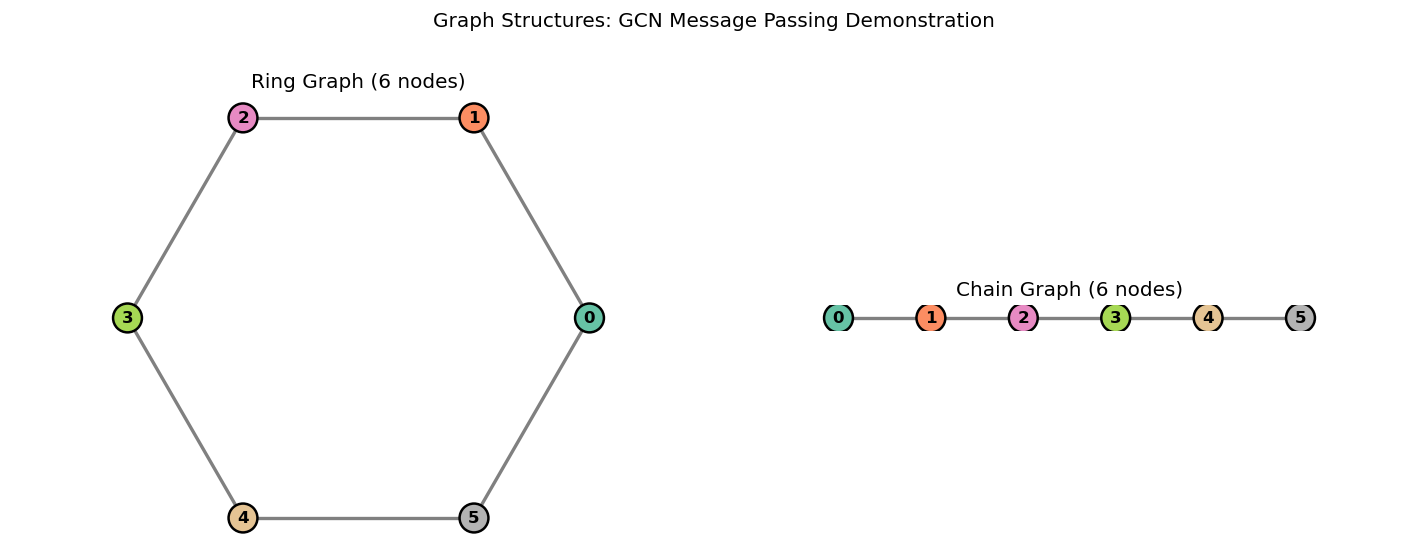

In GCN, node i aggregates information from all its neighbors.
After 2 layers, node i has information about all nodes within 2 hops.
The ring and chain produce different graph-level embeddings,
allowing a classifier to distinguish molecular topology types.


In [5]:
# Visualize the two graph structures
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, A, n) in zip(axes, [
    ('Ring Graph (6 nodes)', A1, n1),
    ('Chain Graph (6 nodes)', A2, n2),
]):
    # Compute layout
    if name.startswith('Ring'):
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        pos = np.column_stack([np.cos(angles), np.sin(angles)])
    else:
        pos = np.column_stack([np.linspace(-1, 1, n), np.zeros(n)])

    # Draw edges
    for i in range(n):
        for j in range(i+1, n):
            if A[i, j] > 0:
                ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                        'gray', lw=2, zorder=1)

    # Draw nodes
    sc = ax.scatter(pos[:,0], pos[:,1], s=300, c=range(n),
                    cmap='Set2', zorder=2, edgecolors='black', lw=1.5)
    for i in range(n):
        ax.text(pos[i,0], pos[i,1], str(i), ha='center', va='center',
                fontsize=10, fontweight='bold')

    ax.set_title(name); ax.set_aspect('equal')
    ax.set_xlim(-1.5, 1.5); ax.axis('off')

plt.suptitle('Graph Structures: GCN Message Passing Demonstration', fontsize=12)
plt.tight_layout(); plt.show()

print('In GCN, node i aggregates information from all its neighbors.')
print('After 2 layers, node i has information about all nodes within 2 hops.')
print('The ring and chain produce different graph-level embeddings,')
print('allowing a classifier to distinguish molecular topology types.')


### Interpretation

- The **ring vs. chain** example illustrates how GCN embeddings encode graph topology:
  each node aggregates its neighbors' features, producing representations that capture
  local neighborhood structure.
- After $L$ layers, each node embeds information from all nodes within $L$ hops.
- **Graph-level representations** (via mean/sum pooling) encode overall molecular properties,
  enabling graph classification tasks like predicting drug toxicity or solubility.
- For production GNN implementations, use `PyTorch Geometric` or `DGL`:

```python
# PyTorch Geometric example (requires: pip install torch-geometric)
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, out_channels)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return global_mean_pool(x, batch)  # graph-level readout
```


---
# 3. AutoML and Hyperparameter Optimization
## Framework

AutoML treats algorithm selection and configuration as a black-box optimization problem:

$$\boldsymbol{\lambda}^* = \underset{\boldsymbol{\lambda}\in\Lambda}{\arg\min}\;\mathcal{L}\!\left(\mathcal{A}(\boldsymbol{\lambda},\mathcal{D}_{\text{train}}),\,\mathcal{D}_{\text{val}}\right)$$

## Key HPO Methods

| Method | Approach | Best for |
|---|---|---|
| Random Search | Uniform sampling in $\Lambda$ | Few evaluations; uninformative priors |
| Bayesian Opt. (GP) | Gaussian Process surrogate + acquisition | Expensive evaluations; low $|\Lambda|$ |
| TPE | Tree-structured Parzen Estimators | High-dimensional $\Lambda$; mixed types |
| Hyperband | Successive halving with adaptive budgets | Many configurations; early stopping |
| BOHB | Bayesian Opt. + Hyperband | Best of both; robust across problem types |

## When to Use / Avoid

| | Condition |
|---|---|
| **Use** | Rapid prototyping; limited tuning expertise; strong baseline needed quickly |
| **Avoid** | Domain-specific constraints must be encoded; full transparency required |


In [6]:
# Manual Bayesian-style HPO vs random search comparison
cancer = load_breast_cancer()
X_hpo, y_hpo = cancer.data, cancer.target
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X_hpo, y_hpo, test_size=0.2, random_state=SEED, stratify=y_hpo)

cv_hpo = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Random Search baseline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth':    randint(2, 12),
    'learning_rate': loguniform(0.005, 0.3),
    'subsample':    loguniform(0.5, 1.0),
    'max_features': ['sqrt', 'log2', None],
}

rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    param_distributions=param_dist,
    n_iter=40, cv=cv_hpo, scoring='roc_auc',
    random_state=SEED, n_jobs=-1
)
rs.fit(X_tr_h, y_tr_h)
rs_test = roc_auc_score(y_te_h, rs.best_estimator_.predict_proba(X_te_h)[:,1])
print(f'Random Search (40 trials):')
print(f'  Best CV AUC:   {rs.best_score_:.4f}')
print(f'  Test AUC:      {rs_test:.4f}')
print(f'  Best params:   {rs.best_params_}')


Random Search (40 trials):
  Best CV AUC:   0.9938
  Test AUC:      0.9950
  Best params:   {'learning_rate': np.float64(0.25590527684627273), 'max_depth': 6, 'max_features': 'sqrt', 'n_estimators': 387, 'subsample': np.float64(0.726831138113444)}


Install Optuna for Bayesian HPO:  pip install optuna


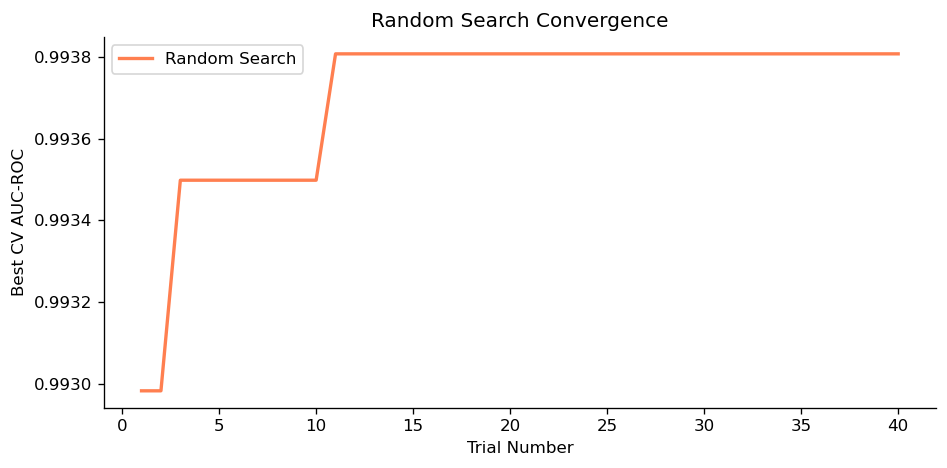

In [7]:
# Optuna (TPE-based Bayesian Optimization)
if OPTUNA_OK:
    def objective(trial):
        params = {
            'n_estimators':  trial.suggest_int('n_estimators', 50, 500),
            'max_depth':     trial.suggest_int('max_depth', 2, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
            'max_features':  trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        model = GradientBoostingClassifier(**params, random_state=SEED)
        score = cross_val_score(model, X_tr_h, y_tr_h, cv=cv_hpo,
                                scoring='roc_auc', n_jobs=-1).mean()
        return score

    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=40, show_progress_bar=False)

    best_model = GradientBoostingClassifier(**study.best_params, random_state=SEED)
    best_model.fit(X_tr_h, y_tr_h)
    optuna_test = roc_auc_score(y_te_h, best_model.predict_proba(X_te_h)[:,1])

    print(f'Optuna TPE (40 trials):')
    print(f'  Best CV AUC:   {study.best_value:.4f}')
    print(f'  Test AUC:      {optuna_test:.4f}')
    print(f'  Best params:   {study.best_params}')

    # Learning curves: best score found vs number of trials
    rs_cv = [max(rs.cv_results_['mean_test_score'][:i+1])
             for i in range(len(rs.cv_results_['mean_test_score']))]
    opt_cv = [max([t.value for t in study.trials[:i+1]]) for i in range(len(study.trials))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(range(1, len(rs_cv)+1), rs_cv, label='Random Search', color='coral', lw=2)
    axes[0].plot(range(1, len(opt_cv)+1), opt_cv, label='Optuna (TPE)', color='steelblue', lw=2)
    axes[0].set_xlabel('Trial Number'); axes[0].set_ylabel('Best CV AUC-ROC')
    axes[0].set_title('HPO Convergence: Random Search vs Bayesian Opt.')
    axes[0].legend()

    # Parameter importance
    importances = optuna.importance.get_param_importances(study)
    names, vals = zip(*list(importances.items())[:6])
    axes[1].barh(names, vals, color='steelblue')
    axes[1].set_xlabel('Importance Score')
    axes[1].set_title('Hyperparameter Importance (Optuna FAnova)')
    plt.tight_layout(); plt.show()
else:
    print('Install Optuna for Bayesian HPO:  pip install optuna')
    # Visualize Random Search results anyway
    rs_cv = [max(rs.cv_results_['mean_test_score'][:i+1])
             for i in range(len(rs.cv_results_['mean_test_score']))]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(rs_cv)+1), rs_cv, color='coral', lw=2, label='Random Search')
    ax.set_xlabel('Trial Number'); ax.set_ylabel('Best CV AUC-ROC')
    ax.set_title('Random Search Convergence'); ax.legend()
    plt.tight_layout(); plt.show()


### Interpretation

- **Bayesian optimization (TPE)** converges faster than random search by using information
  from previous trials to propose promising configurations.
- **Hyperparameter importance** reveals which parameters have the most impact on performance -
  focus manual tuning effort here.
- In practice, **learning rate and number of estimators** typically dominate GBM performance;
  tree depth and subsampling provide secondary regularization.
- **BOHB** (from `pip install hpbandster`) combines TPE with Hyperband's multi-fidelity evaluation,
  achieving the best efficiency for expensive pipelines.


---
# 4. Consolidated Algorithm Selection Guide

## The Six-Step Practitioner Workflow

| Step | Action | Tools |
|---|---|---|
| 1 | Establish baseline | Logistic/Linear Regression |
| 2 | Strong untuned baseline | Random Forest (default params) |
| 3 | Tune for accuracy | XGBoost/LightGBM + early stopping + Optuna |
| 4 | Unstructured/graph data | Pre-trained Transformer or GNN |
| 5 | Ensemble (if justified) | Stacking with diverse base models |
| 6 | Rigorous evaluation | Nested CV + statistical tests + fairness audit |

## Full Algorithm Taxonomy Reference

| Algorithm | Notebook | Paradigm | Primary Strength |
|---|---|---|---|
| Linear / Logistic Regression | 1 | Supervised | Interpretability; baseline |
| Decision Tree | 1 | Supervised | Human-readable rules |
| Random Forest | 1 | Supervised | Robust; minimal tuning |
| Gradient Boosting | 1 | Supervised | Max accuracy on tabular data |
| Stacking / Blending | 1 | Supervised | Complementary error correction |
| SVM | 1 | Supervised | High-dim; clear margin |
| k-NN | 1 | Supervised | Prototype-based explanation |
| Naive Bayes | 1 | Supervised | Real-time; sparse text |
| K-Means | 2 | Unsupervised | Spherical clusters; scalable |
| DBSCAN | 2 | Unsupervised | Arbitrary shapes; outlier detection |
| GMM | 2 | Unsupervised | Soft assignments; elliptical clusters |
| PCA | 2 | Unsupervised | Linear dimensionality reduction |
| t-SNE / UMAP | 2 | Unsupervised | 2D/3D visualization |
| Isolation Forest | 2 | Unsupervised | Fast anomaly detection |
| Bayesian Network | 3 | Probabilistic | Causal structure; interpretable inference |
| HMM | 3 | Probabilistic | Latent sequential dynamics |
| ARIMA / Prophet | 4 | Time Series | Univariate forecasting |
| Neural ODE | 4 | Time Series | Irregular sampling; continuous dynamics |
| Evaluation Framework | 5 | Methodology | Metrics; CV; significance testing |
| Causal ML (DML) | 6 | Causal | Intervention effects; ATE/CATE |
| GNN | 6 | Graph | Relational; molecular; network data |
| AutoML / HPO | 6 | Meta | Automated pipeline optimization |
